In [135]:
import numpy as np
import matplotlib.pyplot as plt
import os
from __future__ import division, print_function, unicode_literals
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from pandas import *
import time
from sklearn.naive_bayes import GaussianNB
from pathlib import Path

# A. PHƯƠNG PHÁP K-NN CHO PHÂN LOẠI NHỊ PHÂN (K-NN BINARY CLASSIFIER)

## Ví dụ A.1.

In [136]:
np.random.seed(2)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,
2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

In [137]:
def knn_regress_predict(x_train, y_train, x_query, k):
    x_train = np.asarray(x_train)
    y_train = np.asarray(y_train)
    x_query = np.asarray(x_query)
    if x_train.ndim == 1:
        x_train_2d = x_train.reshape(-1, 1)
    else:
        x_train_2d = x_train
    if x_query.ndim == 1:
        x_query_2d = x_query.reshape(-1, 1)
    else:
        x_query_2d = x_query
    
    diff = x_query_2d[:, None, :] - x_train_2d[None, :, :]
    dist_sq = np.sum(diff * diff, axis=2)
    k = int(k)
    idx_part = np.argpartition(dist_sq, k-1, axis=1)[:, :k]  
    y_neighbors = y_train[idx_part]  
    y_pred = np.mean(y_neighbors, axis=1)
    return y_pred

x = X.flatten()
y = y
x_queries = np.array([2.45, 1.85, 3.75, 3.21, 4.05])
ks = [3, 4, 5]
results = {}
for k in ks:
    y_pred = knn_regress_predict(x, y, x_queries, k)
    results[k] = y_pred
    print(f'K={k} predictions for queries {x_queries}:')
    print(y_pred)

K=3 predictions for queries [2.45 1.85 3.75 3.21 4.05]:
[0.66666667 0.33333333 0.66666667 0.33333333 1.        ]
K=4 predictions for queries [2.45 1.85 3.75 3.21 4.05]:
[0.5  0.25 0.75 0.5  0.75]
K=5 predictions for queries [2.45 1.85 3.75 3.21 4.05]:
[0.4 0.4 0.6 0.4 0.8]


## Ví dụ A.2.

In [138]:
data_path = r'd:\\Workspace\\HUS\\Machine Learning\\3. LR\\vidu4_lin_reg.txt'

with open(data_path, 'r', encoding='utf-8') as f:
    raw = f.read().strip().splitlines()
# Skip header line if present (first line contains column names)
if raw and raw[0].strip().split()[0].upper() == 'ID':
    raw = raw[1:]
rows = []
for line in raw:
    parts = line.strip().split()
    parts = [tok if not tok.startswith('.') else '0'+tok for tok in parts]
    rows.append(parts)
arr = np.array(rows)
X_all = arr[:, 1:6].astype(float)  # TUOI, BMI, HA, GLUCOSE, CHOLESTEROL
beday = arr[:, 6].astype(float)
y_all = (beday >= 1.0).astype(int)
X_train = X_all[:80].astype(float)
y_train = y_all[:80].astype(int)
X_val = X_all[80:100].astype(float)
y_val = y_all[80:100].astype(int)

def knn_classify(x_train, y_train, x_query, k):
    x_train = np.asarray(x_train)
    y_train = np.asarray(y_train)
    x_query = np.asarray(x_query)
    # Ensure shapes: x_train (n,d), x_query (m,d)
    if x_train.ndim == 1:
        x_train = x_train.reshape(-1,1)
    if x_query.ndim == 1:
        x_query = x_query.reshape(-1,1)
    diff = x_query[:, None, :] - x_train[None, :, :]
    dist_sq = np.sum(diff*diff, axis=2)
    k = int(k)
    idx = np.argpartition(dist_sq, k-1, axis=1)[:, :k]  
    neighs = y_train[idx]
    preds = np.array([np.bincount(row.astype(int), minlength=2).argmax() for row in neighs])
    return preds

# Metrics: accuracy, precision, recall, confusion matrix 
def confusion_matrix_bin(y_true, y_pred):
    tp = int(np.sum((y_true==1) & (y_pred==1)))
    tn = int(np.sum((y_true==0) & (y_pred==0)))
    fp = int(np.sum((y_true==0) & (y_pred==1)))
    fn = int(np.sum((y_true==1) & (y_pred==0)))
    return np.array([[tn, fp],[fn, tp]])
def accuracy(y_true, y_pred):
    return np.mean(y_true==y_pred)
def precision(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1))
    fp = np.sum((y_true==0)&(y_pred==1))
    return tp / (tp+fp) if (tp+fp)>0 else 0.0
def recall(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    return tp / (tp+fn) if (tp+fn)>0 else 0.0

# Run K-NN for K values and print metrics
ks = [3,5,7]
for k in ks:
    y_pred = knn_classify(X_train, y_train, X_val, k)
    cm = confusion_matrix_bin(y_val, y_pred)
    acc = accuracy(y_val, y_pred)
    prec = precision(y_val, y_pred)
    rec = recall(y_val, y_pred)
    print(f'K={k} -> Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}')
    print('Confusion matrix (tn,fp; fn,tp):')
    print(cm)

K=3 -> Accuracy=0.6500, Precision=0.6250, Recall=0.5556
Confusion matrix (tn,fp; fn,tp):
[[8 3]
 [4 5]]
K=5 -> Accuracy=0.7000, Precision=0.7143, Recall=0.5556
Confusion matrix (tn,fp; fn,tp):
[[9 2]
 [4 5]]
K=7 -> Accuracy=0.6000, Precision=0.5714, Recall=0.4444
Confusion matrix (tn,fp; fn,tp):
[[8 3]
 [5 4]]


# B. PHƯƠNG PHÁP HỒI QUY LOGISTIC

## Ví dụ B.1.

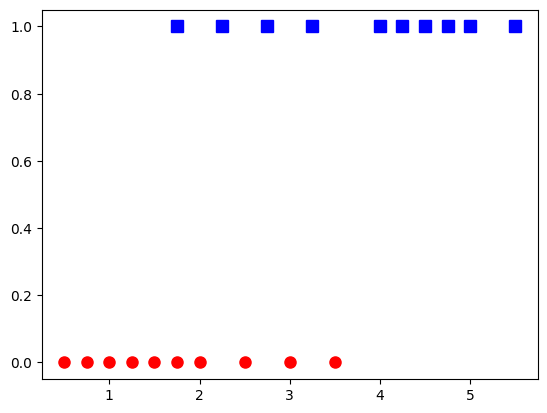

In [139]:
np.random.seed(2)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,
2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data by adding a column of 1s (x_0 = 1)
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)


X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)
plt.show()

In [140]:
def sigmoid(s):
    """Numerically-stable sigmoid for NumPy arrays."""
    s = np.asarray(s, dtype=float)
    out = np.empty_like(s, dtype=float)
    # For non-negative s, use standard formulation
    pos = s >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-s[pos]))
    # For negative s, compute exp(s)/(1+exp(s)) to avoid overflow in exp(-s)
    neg = ~pos
    if np.any(neg):
        exp_s = np.exp(s[neg])
        out[neg] = exp_s / (1.0 + exp_s)
    return out

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    # loop of stochastic gradient descent
    while count < max_count:
        # shuffle the order of data (for stochastic gradient descent).
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

In [141]:
eta = .05
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

print(sigmoid(np.dot(w[-1].T, X)))

[[-4.092695  ]
 [ 1.55277242]]
[[0.03501592 0.05078108 0.07310642 0.10416972 0.14634799 0.20175793
  0.20175793 0.27147534 0.35458234 0.4475032  0.54424128 0.63775242
  0.72188183 0.79282004 0.89267823 0.92460236 0.94758783 0.96384008
  0.97518471 0.9884283 ]]


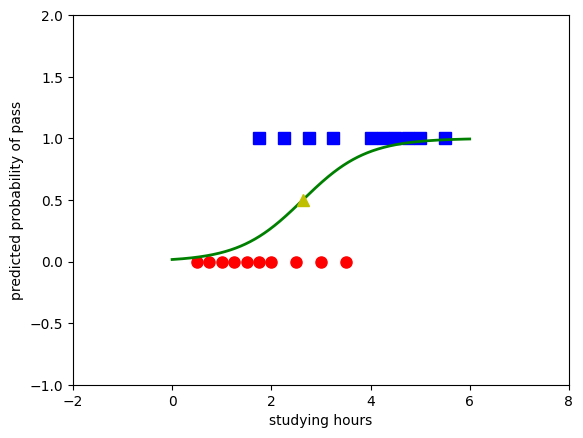

In [142]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

In [143]:
query_hours = np.array([2.45, 1.85, 3.75, 3.21, 4.05])
# Logistic: use learned weights w from training above (w[-1])
w_final = w[-1].reshape(-1)  # shape (d,)
# Build input matrix for logistic: x0=1 then hour value
Xq = np.vstack((np.ones(query_hours.shape), query_hours)).T  # shape (m, d) where d=2
# compute probabilities: sigmoid(w0 + w1 * x)
logit_scores = 1/(1 + np.exp(- (Xq @ w_final)))
logit_probs = logit_scores.flatten()
logit_classes = (logit_probs >= 0.5).astype(int)
knn_probs_k3 = results[3]
knn_probs_k4 = results[4]
knn_probs_k5 = results[5]
knn_cls_k3 = (knn_probs_k3 >= 0.5).astype(int)
knn_cls_k4 = (knn_probs_k4 >= 0.5).astype(int)
knn_cls_k5 = (knn_probs_k5 >= 0.5).astype(int)
# Print a table comparing
print('ID	Hours	Logit_prob	Logit_cls	K3_prob	K3_cls	K4_prob	K4_cls	K5_prob	K5_cls')
for i, h in enumerate(query_hours, start=21):
    print(f'{i}	{h:.2f}	{logit_probs[i-21]:.3f}		{logit_classes[i-21]}		{knn_probs_k3[i-21]:.3f}		{knn_cls_k3[i-21]}		{knn_probs_k4[i-21]:.3f}		{knn_cls_k4[i-21]}		{knn_probs_k5[i-21]:.3f}		{knn_cls_k5[i-21]}')

ID	Hours	Logit_prob	Logit_cls	K3_prob	K3_cls	K4_prob	K4_cls	K5_prob	K5_cls
21	2.45	0.428		0		0.667		1		0.500		1		0.400		0
22	1.85	0.228		0		0.333		0		0.250		0		0.400		0
23	3.75	0.849		1		0.667		1		0.750		1		0.600		1
24	3.21	0.709		1		0.333		0		0.500		1		0.400		0
25	4.05	0.900		1		1.000		1		0.750		1		0.800		1


## Ví dụ B.2.

In [144]:
np.random.seed(22)
means = [[2, 2], [4, 2]]
cov = [[.7, 0], [0, .7]]
N = 20

In [145]:
X1 = np.random.multivariate_normal(means[0], cov, N)
X2 = np.random.multivariate_normal(means[1], cov, N)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


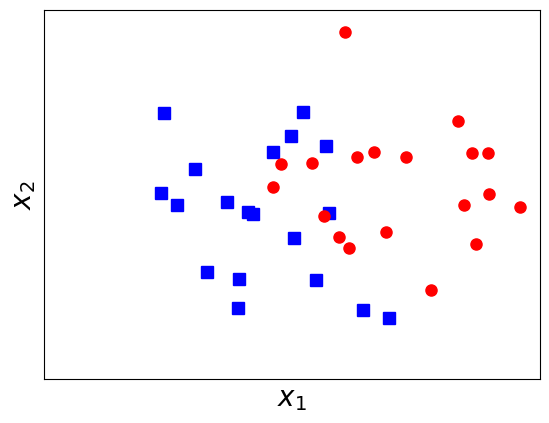

In [146]:
plt.plot(X1[:, 0], X1[:, 1], 'bs', markersize = 8, alpha = 1)
plt.plot(X2[:, 0], X2[:, 1], 'ro', markersize = 8, alpha = 1)
plt.axis('equal')
plt.ylim(0, 4)
plt.xlim(0, 5)
# hide tikcs
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
# save the figure to an image first
plt.show()

In [147]:
X = np.concatenate((X1, X2), axis = 0).T
y = np.concatenate((np.zeros((1, N)), np.ones((1, N))), axis = 1).T
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)
eta = 0.05
d = X.shape[0]
w_init = np.random.randn(d, 1) # initialize parameters w = w_init
w = logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count= 10000)
# print out the parameter
print(w[-1])


[[-9.51043127]
 [ 2.25978315]
 [ 1.42588178]]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


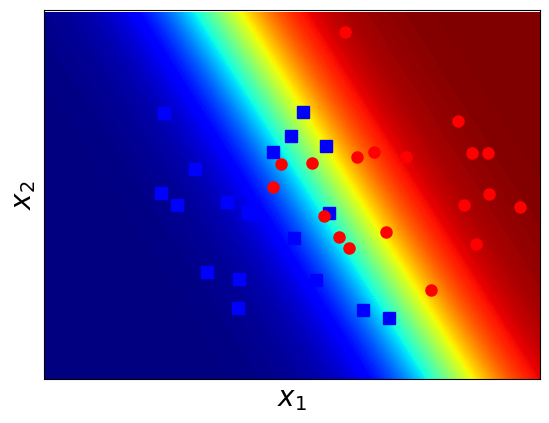

In [148]:
# Make data.
x1m = np.arange(-1, 6, 0.025) # generate data coord. X1
xlen = len(x1m)
x2m = np.arange(0, 4, 0.025) # generate data coord. X2
x2en = len(x2m)
x1m, x2m = np.meshgrid(x1m, x2m) # create mesh grid X = (X1, X2)
# now assign the parameter w0, w1, w2 from array w which was computed above
w0 = w[-1][0][0]
w1 = w[-1][1][0]
w2 = w[-1][2][0]
# calculate probability zm=P(c|x)=sigmoid(w^Tx)=sigmoid(w0+w1*x1m+w2*x2m)
zm = sigmoid(w0 + w1*x1m + w2*x2m)
# plot contour of prob. zm by the saturation of blue and red
# more red <=> prob. that data point belong to red class is higher & vise versa
CS = plt.contourf(x1m, x2m, zm, 200, cmap='jet')
# finally, plot the data and take a look
plt.plot(X1[:, 0], X1[:, 1], 'bs', markersize = 8, alpha = 1)
plt.plot(X2[:, 0], X2[:, 1], 'ro', markersize = 8, alpha = 1)
plt.axis('equal')
plt.ylim(0, 4)
plt.xlim(0, 5)
# hide tikcs
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
plt.show()

## Ví dụ B.3. (Bài tập 1)

### a. Phân loại bằng hồi quy logistic

In [149]:
data = read_csv("D:/Workspace/HUS/Machine Learning/3. LR/Admission_Predict.csv")
sn = data['Serial No.'].tolist()

gre = data['GRE Score'].tolist()
X1 = np.asarray(gre)

tfl = data['TOEFL Score'].tolist()
X2 = np.asarray(tfl)

unirt = data['University Rating'].tolist()
X3 = np.asarray(unirt)

sop = data['SOP'].tolist()
X4 = np.asarray(sop)

lor1 = data['LOR '].tolist()
X5 = np.asarray(lor1)

cgpa1 = data['CGPA'].tolist()
X6 = np.asarray(cgpa1)

research_exp = data['Research'].tolist()
X7 = np.asarray(research_exp)

prob_Admit = data['Chance of Admit'].tolist()
Yt = np.asarray(prob_Admit)

In [150]:
cols = ['GRE Score','TOEFL Score','University Rating','SOP','LOR ','CGPA','Research']
X_full = data[cols].to_numpy(dtype=float)  # shape (n_samples, n_features)
y_prob = data['Chance of Admit'].to_numpy(dtype=float)
# Binary label: 1 if Chance >= 0.75, else 0
y_bin = (y_prob >= 0.75).astype(int)
# Split: first 350 for training, remaining for test 
X_train_full = X_full[:350]
y_train_full = y_bin[:350]
X_test_full = X_full[350:]
y_test_full = y_bin[350:]
# Build design matrices with intercept and transpose to match logistic_sigmoid_regression (d x N)
Xbar_train = np.concatenate((np.ones((1, X_train_full.shape[0])), X_train_full.T), axis=0)
Xbar_test = np.concatenate((np.ones((1, X_test_full.shape[0])), X_test_full.T), axis=0)
# initialize weights and train using provided SGD logistic function
d = Xbar_train.shape[0]
w_init = np.random.randn(d, 1)
w_list = logistic_sigmoid_regression(Xbar_train, y_train_full, w_init, eta=0.01, tol=1e-5, max_count=20000)
w_final = w_list[-1].reshape(-1)
print('Learned weights (w_final):')
print(w_final)
# Predict probs on test set
probs_test = 1/(1 + np.exp(- (Xbar_test.T @ w_final)))
preds_test = (probs_test >= 0.5).astype(int)  # default threshold 0.5 for classification
# Compute sklearn metrics
acc = accuracy_score(y_test_full, preds_test)
prec = precision_score(y_test_full, preds_test, zero_division=0)
rec = recall_score(y_test_full, preds_test, zero_division=0)
cm = confusion_matrix(y_test_full, preds_test)
print(f'On test set (n={len(y_test_full)}): Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}')
print('Confusion matrix (rows: true 0/1, cols: pred 0/1):')
print(cm)

Learned weights (w_final):
[ -0.70810368 -18.73574992  51.61816457  36.50068167  29.57318788
  23.53055209   9.88065143  13.34781638]
On test set (n=50): Accuracy=0.7600, Precision=0.8571, Recall=0.5455
Confusion matrix (rows: true 0/1, cols: pred 0/1):
[[26  2]
 [10 12]]


### b. Dự đoán bằng hồi quy tuyến tính

In [151]:
# Implement linear regression using NumPy
# Use same data split as before: first 350 for training
X_train = X_full[:350]
y_train = y_prob[:350]  # Use actual probabilities, not binary
X_test = X_full[350:]
y_test = y_prob[350:]

# Add bias term (column of 1's)
X_train_bias = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test_bias = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

# Calculate weights using normal equation: w = (X^T X)^(-1) X^T y
weights = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

# Make predictions on test set
y_pred = X_test_bias @ weights

# Calculate MSE
mse = np.mean((y_test - y_pred) ** 2)

print("Linear Regression Weights:")
for i, col in enumerate(['Bias'] + cols):
    print(f"{col}: {weights[i]:.4f}")
print(f"\nMean Squared Error on test set: {mse:.6f}")

# Print some sample predictions vs actual values
print("\nSample predictions vs actual values:")
for i in range(5):
    print(f"Actual: {y_test[i]:.3f}, Predicted: {y_pred[i]:.3f}")

Linear Regression Weights:
Bias: -1.1950
GRE Score: 0.0015
TOEFL Score: 0.0032
University Rating: 0.0093
SOP: -0.0044
LOR : 0.0249
CGPA: 0.1124
Research: 0.0219

Mean Squared Error on test set: 0.004642

Sample predictions vs actual values:
Actual: 0.740, Predicted: 0.698
Actual: 0.730, Predicted: 0.783
Actual: 0.640, Predicted: 0.619
Actual: 0.630, Predicted: 0.594
Actual: 0.590, Predicted: 0.527


In [152]:
# Calculate additional metrics
# 1. R-squared (coefficient of determination)
y_mean = np.mean(y_test)
ss_tot = np.sum((y_test - y_mean) ** 2)  # Total sum of squares
ss_res = np.sum((y_test - y_pred) ** 2)  # Residual sum of squares
r2 = 1 - (ss_res / ss_tot)

# 2. RMSE (Root Mean Square Error)
rmse = np.sqrt(mse)

# 3. MAE (Mean Absolute Error)
mae = np.mean(np.abs(y_test - y_pred))

print("\nAdditional Evaluation Metrics:")
print(f"R-squared (R²): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Calculate and print residual statistics
residuals = y_test - y_pred
print("\nResidual Statistics:")
print(f"Mean of residuals: {np.mean(residuals):.4f}")
print(f"Std of residuals: {np.std(residuals):.4f}")
print(f"Min residual: {np.min(residuals):.4f}")
print(f"Max residual: {np.max(residuals):.4f}")


Additional Evaluation Metrics:
R-squared (R²): 0.8137
RMSE: 0.0681
MAE: 0.0504

Residual Statistics:
Mean of residuals: 0.0154
Std of residuals: 0.0664
Min residual: -0.1754
Max residual: 0.1650


### c. Bài tập thực hành (Naive Bayes)

In [153]:
print("="*70)
print("PHÂN LOẠI DỮ LIỆU ADMISSION BẰNG NAIVE BAYES VÀ LOGISTIC REGRESSION")
print("="*70)

print(f"\nThông tin dữ liệu:")
print(f"Training set: {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features")
print(f"Test set: {X_test_full.shape[0]} samples")
print(f"Features: {cols}")
print(f"Binary classification: Admit (1) vs Not Admit (0), threshold = 0.75")

# ============================================================================
# 1. NAIVE BAYES CLASSIFIER
# ============================================================================
print("\n" + "="*70)
print("1. NAIVE BAYES CLASSIFIER (Gaussian Naive Bayes)")
print("="*70)

# Khởi tạo mô hình Gaussian Naive Bayes
gnb = GaussianNB()

# Đo thời gian training
start_time_nb_train = time.time()
gnb.fit(X_train_full, y_train_full)
end_time_nb_train = time.time()
time_nb_train = end_time_nb_train - start_time_nb_train

print(f"\n  Thời gian training: {time_nb_train:.6f} seconds")

# Đo thời gian prediction
start_time_nb_pred = time.time()
y_pred_nb = gnb.predict(X_test_full)
end_time_nb_pred = time.time()
time_nb_pred = end_time_nb_pred - start_time_nb_pred

print(f"Thời gian prediction: {time_nb_pred:.6f} seconds")
print(f"Tổng thời gian: {time_nb_train + time_nb_pred:.6f} seconds")

# Tính các metrics
acc_nb = accuracy_score(y_test_full, y_pred_nb)
prec_nb = precision_score(y_test_full, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test_full, y_pred_nb, zero_division=0)
cm_nb = confusion_matrix(y_test_full, y_pred_nb)

print(f"\n Kết quả đánh giá trên test set:")
print(f"   Accuracy:  {acc_nb:.4f} ({acc_nb*100:.2f}%)")
print(f"   Precision: {prec_nb:.4f} ({prec_nb*100:.2f}%)")
print(f"   Recall:    {rec_nb:.4f} ({rec_nb*100:.2f}%)")

print(f"\n Confusion Matrix:")
print(f"   Predicted:   0    1")
print(f"   Actual 0:  {cm_nb[0,0]:3d}  {cm_nb[0,1]:3d}")
print(f"   Actual 1:  {cm_nb[1,0]:3d}  {cm_nb[1,1]:3d}")

# Thêm thông tin về prior probabilities và class distributions
print(f"\n Prior Probabilities (từ training data):")
print(f"   Class 0 (Not Admit): {gnb.class_prior_[0]:.4f}")
print(f"   Class 1 (Admit):     {gnb.class_prior_[1]:.4f}")

# ============================================================================
# 2. LOGISTIC REGRESSION (đã train ở phần trước)
# ============================================================================
print("\n" + "="*70)
print("2. LOGISTIC REGRESSION (Stochastic Gradient Descent)")
print("="*70)

# Đo lại thời gian cho Logistic Regression để so sánh công bằng
start_time_lr_train = time.time()
w_init_lr = np.random.randn(d, 1)
w_list_lr = logistic_sigmoid_regression(Xbar_train, y_train_full, w_init_lr, eta=0.01, tol=1e-5, max_count=20000)
w_final_lr = w_list_lr[-1].reshape(-1)
end_time_lr_train = time.time()
time_lr_train = end_time_lr_train - start_time_lr_train

print(f"\n Thời gian training: {time_lr_train:.6f} seconds")

# Đo thời gian prediction
start_time_lr_pred = time.time()
probs_test_lr = 1/(1 + np.exp(- (Xbar_test.T @ w_final_lr)))
preds_test_lr = (probs_test_lr >= 0.5).astype(int)
end_time_lr_pred = time.time()
time_lr_pred = end_time_lr_pred - start_time_lr_pred

print(f"Thời gian prediction: {time_lr_pred:.6f} seconds")
print(f"Tổng thời gian: {time_lr_train + time_lr_pred:.6f} seconds")

# Tính các metrics
acc_lr = accuracy_score(y_test_full, preds_test_lr)
prec_lr = precision_score(y_test_full, preds_test_lr, zero_division=0)
rec_lr = recall_score(y_test_full, preds_test_lr, zero_division=0)
cm_lr = confusion_matrix(y_test_full, preds_test_lr)

print(f"\nKết quả đánh giá trên test set:")
print(f"   Accuracy:  {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"   Precision: {prec_lr:.4f} ({prec_lr*100:.2f}%)")
print(f"   Recall:    {rec_lr:.4f} ({rec_lr*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"   Predicted:   0    1")
print(f"   Actual 0:  {cm_lr[0,0]:3d}  {cm_lr[0,1]:3d}")
print(f"   Actual 1:  {cm_lr[1,0]:3d}  {cm_lr[1,1]:3d}")

# ============================================================================
# 3. SO SÁNH KẾT QUẢ
# ============================================================================
print("\n" + "="*70)
print("3. SO SÁNH KẾT QUẢ GIỮA HAI PHƯƠNG PHÁP")
print("="*70)

print(f"\n{'Metric':<20} {'Naive Bayes':<15} {'Logistic Reg':<15} {'Winner':<15}")
print("-" * 70)

# So sánh Accuracy
winner_acc = "Naive Bayes" if acc_nb > acc_lr else ("Logistic Reg" if acc_lr > acc_nb else "Tie")
print(f"{'Accuracy':<20} {acc_nb:<15.4f} {acc_lr:<15.4f} {winner_acc:<15}")

# So sánh Precision
winner_prec = "Naive Bayes" if prec_nb > prec_lr else ("Logistic Reg" if prec_lr > prec_nb else "Tie")
print(f"{'Precision':<20} {prec_nb:<15.4f} {prec_lr:<15.4f} {winner_prec:<15}")

# So sánh Recall
winner_rec = "Naive Bayes" if rec_nb > rec_lr else ("Logistic Reg" if rec_lr > rec_nb else "Tie")
print(f"{'Recall':<20} {rec_nb:<15.4f} {rec_lr:<15.4f} {winner_rec:<15}")

# So sánh F1-Score
f1_nb = 2 * (prec_nb * rec_nb) / (prec_nb + rec_nb) if (prec_nb + rec_nb) > 0 else 0
f1_lr = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr) if (prec_lr + rec_lr) > 0 else 0
winner_f1 = "Naive Bayes" if f1_nb > f1_lr else ("Logistic Reg" if f1_lr > f1_nb else "Tie")
print(f"{'F1-Score':<20} {f1_nb:<15.4f} {f1_lr:<15.4f} {winner_f1:<15}")

print("\n" + "-" * 70)

# So sánh thời gian
total_time_nb = time_nb_train + time_nb_pred
total_time_lr = time_lr_train + time_lr_pred
winner_time = "Naive Bayes" if total_time_nb < total_time_lr else "Logistic Reg"

print(f"{'Training Time (s)':<20} {time_nb_train:<15.6f} {time_lr_train:<15.6f}")
print(f"{'Prediction Time (s)':<20} {time_nb_pred:<15.6f} {time_lr_pred:<15.6f}")
print(f"{'Total Time (s)':<20} {total_time_nb:<15.6f} {total_time_lr:<15.6f} {winner_time:<15}")

# ============================================================================
# 4. PHÂN TÍCH VÀ KẾT LUẬN
# ============================================================================
print("\n" + "="*70)
print("4. PHÂN TÍCH VÀ KẾT LUẬN")
print("="*70)

if acc_nb > acc_lr:
    print(f"\nKết luận: Naive Bayes đạt độ chính xác cao hơn ({acc_nb:.4f} vs {acc_lr:.4f})")
elif acc_lr > acc_nb:
    print(f"\nKết luận: Logistic Regression đạt độ chính xác cao hơn ({acc_lr:.4f} vs {acc_nb:.4f})")
else:
    print(f"\nKết luận: Cả hai phương pháp đạt độ chính xác tương đương ({acc_nb:.4f})")

print(f"\n💡 Lưu ý: Naive Bayes giả định các features độc lập có điều kiện,")
print(f"   trong khi dữ liệu thực tế (GRE, TOEFL, CGPA, etc.) có correlation cao,")
print(f"   điều này có thể ảnh hưởng đến hiệu suất của Naive Bayes.")

PHÂN LOẠI DỮ LIỆU ADMISSION BẰNG NAIVE BAYES VÀ LOGISTIC REGRESSION

Thông tin dữ liệu:
Training set: 350 samples, 7 features
Test set: 50 samples
Features: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
Binary classification: Admit (1) vs Not Admit (0), threshold = 0.75

1. NAIVE BAYES CLASSIFIER (Gaussian Naive Bayes)

  Thời gian training: 0.001197 seconds
Thời gian prediction: 0.000214 seconds
Tổng thời gian: 0.001411 seconds

 Kết quả đánh giá trên test set:
   Accuracy:  0.9000 (90.00%)
   Precision: 0.9474 (94.74%)
   Recall:    0.8182 (81.82%)

 Confusion Matrix:
   Predicted:   0    1
   Actual 0:   27    1
   Actual 1:    4   18

 Prior Probabilities (từ training data):
   Class 0 (Not Admit): 0.5486
   Class 1 (Admit):     0.4514

2. LOGISTIC REGRESSION (Stochastic Gradient Descent)

 Thời gian training: 0.400182 seconds
Thời gian prediction: 0.000142 seconds
Tổng thời gian: 0.400324 seconds

Kết quả đánh giá trên test set:
   Accuracy: 

### d. Sử dụng thư viện Scikit-Learn

In [154]:
print("="*80)
print("SO SÁNH 4 PHƯƠNG PHÁP: NAIVE BAYES vs LOGISTIC REGRESSION vs LINEAR REGRESSION")
print("="*80)

from sklearn import linear_model
from sklearn.linear_model import LinearRegression

# ============================================================================
# 1. LOGISTIC REGRESSION - SCIKIT-LEARN
# ============================================================================
print("\n" + "="*80)
print("1. LOGISTIC REGRESSION (Scikit-Learn)")
print("="*80)

# Khởi tạo mô hình Logistic Regression với penalty=None (không regularization)
logReg_sklearn = linear_model.LogisticRegression(penalty=None, max_iter=10000, solver='lbfgs')

# Đo thời gian training
start_time_lr_sklearn_train = time.time()
logReg_sklearn.fit(X_train_full, y_train_full)
end_time_lr_sklearn_train = time.time()
time_lr_sklearn_train = end_time_lr_sklearn_train - start_time_lr_sklearn_train

print(f"\nThời gian training: {time_lr_sklearn_train:.6f} seconds")

# Đo thời gian prediction
start_time_lr_sklearn_pred = time.time()
y_pred_lr_sklearn = logReg_sklearn.predict(X_test_full)
end_time_lr_sklearn_pred = time.time()
time_lr_sklearn_pred = end_time_lr_sklearn_pred - start_time_lr_sklearn_pred

print(f"Thời gian prediction: {time_lr_sklearn_pred:.6f} seconds")
print(f"Tổng thời gian: {time_lr_sklearn_train + time_lr_sklearn_pred:.6f} seconds")

# Hiển thị weights
print(f"\nLearned weights (sklearn):")
print(f"   Intercept (w0): {logReg_sklearn.intercept_[0]:.6f}")
for i, col in enumerate(cols):
    print(f"   {col:<20}: {logReg_sklearn.coef_[0][i]:.6f}")

# Tính các metrics
acc_lr_sklearn = accuracy_score(y_test_full, y_pred_lr_sklearn)
prec_lr_sklearn = precision_score(y_test_full, y_pred_lr_sklearn, zero_division=0)
rec_lr_sklearn = recall_score(y_test_full, y_pred_lr_sklearn, zero_division=0)
cm_lr_sklearn = confusion_matrix(y_test_full, y_pred_lr_sklearn)

print(f"\nKết quả đánh giá trên test set:")
print(f"   Accuracy:  {acc_lr_sklearn:.4f} ({acc_lr_sklearn*100:.2f}%)")
print(f"   Precision: {prec_lr_sklearn:.4f} ({prec_lr_sklearn*100:.2f}%)")
print(f"   Recall:    {rec_lr_sklearn:.4f} ({rec_lr_sklearn*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"   Predicted:   0    1")
print(f"   Actual 0:  {cm_lr_sklearn[0,0]:3d}  {cm_lr_sklearn[0,1]:3d}")
print(f"   Actual 1:  {cm_lr_sklearn[1,0]:3d}  {cm_lr_sklearn[1,1]:3d}")

# ============================================================================
# 2. LINEAR REGRESSION - SCIKIT-LEARN (cho regression task)
# ============================================================================
print("\n" + "="*80)
print("2. LINEAR REGRESSION (Scikit-Learn)")
print("="*80)

# Khởi tạo mô hình Linear Regression
linReg_sklearn = LinearRegression()

# Đo thời gian training
start_time_linreg_train = time.time()
linReg_sklearn.fit(X_train_full, y_prob[:350])  # Train trên giá trị xác suất thực
end_time_linreg_train = time.time()
time_linreg_train = end_time_linreg_train - start_time_linreg_train

print(f"\nThời gian training: {time_linreg_train:.6f} seconds")

# Đo thời gian prediction
start_time_linreg_pred = time.time()
y_pred_linreg = linReg_sklearn.predict(X_test_full)
# Clip predictions to [0, 1] range
y_pred_linreg_clipped = np.clip(y_pred_linreg, 0, 1)
# Convert to binary classification (threshold 0.5)
y_pred_linreg_binary = (y_pred_linreg_clipped >= 0.5).astype(int)
end_time_linreg_pred = time.time()
time_linreg_pred = end_time_linreg_pred - start_time_linreg_pred

print(f"Thời gian prediction: {time_linreg_pred:.6f} seconds")
print(f"Tổng thời gian: {time_linreg_train + time_linreg_pred:.6f} seconds")

# Hiển thị weights
print(f"\nLearned weights (Linear Regression):")
print(f"   Intercept (w0): {linReg_sklearn.intercept_:.6f}")
for i, col in enumerate(cols):
    print(f"   {col:<20}: {linReg_sklearn.coef_[i]:.6f}")

# Tính regression metrics
y_test_prob = y_prob[350:]
mse_linreg = np.mean((y_test_prob - y_pred_linreg_clipped) ** 2)
rmse_linreg = np.sqrt(mse_linreg)
mae_linreg = np.mean(np.abs(y_test_prob - y_pred_linreg_clipped))

print(f"\nRegression metrics (dự đoán xác suất):")
print(f"   MSE:  {mse_linreg:.6f}")
print(f"   RMSE: {rmse_linreg:.6f}")
print(f"   MAE:  {mae_linreg:.6f}")

# Tính classification metrics
acc_linreg = accuracy_score(y_test_full, y_pred_linreg_binary)
prec_linreg = precision_score(y_test_full, y_pred_linreg_binary, zero_division=0)
rec_linreg = recall_score(y_test_full, y_pred_linreg_binary, zero_division=0)
cm_linreg = confusion_matrix(y_test_full, y_pred_linreg_binary)

print(f"\nClassification metrics (threshold = 0.5):")
print(f"   Accuracy:  {acc_linreg:.4f} ({acc_linreg*100:.2f}%)")
print(f"   Precision: {prec_linreg:.4f} ({prec_linreg*100:.2f}%)")
print(f"   Recall:    {rec_linreg:.4f} ({rec_linreg*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"   Predicted:   0    1")
print(f"   Actual 0:  {cm_linreg[0,0]:3d}  {cm_linreg[0,1]:3d}")
print(f"   Actual 1:  {cm_linreg[1,0]:3d}  {cm_linreg[1,1]:3d}")

# ============================================================================
# 3. SO SÁNH TẤT CẢ CÁC PHƯƠNG PHÁP
# ============================================================================
print("\n" + "="*80)
print("3. BẢNG SO SÁNH TẤT CẢ CÁC PHƯƠNG PHÁP")
print("="*80)

# Tính F1-score cho tất cả các phương pháp
f1_nb = 2 * (prec_nb * rec_nb) / (prec_nb + rec_nb) if (prec_nb + rec_nb) > 0 else 0
f1_lr_custom = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr) if (prec_lr + rec_lr) > 0 else 0
f1_lr_sklearn = 2 * (prec_lr_sklearn * rec_lr_sklearn) / (prec_lr_sklearn + rec_lr_sklearn) if (prec_lr_sklearn + rec_lr_sklearn) > 0 else 0
f1_linreg = 2 * (prec_linreg * rec_linreg) / (prec_linreg + rec_linreg) if (prec_linreg + rec_linreg) > 0 else 0

print(f"\n{'Metric':<25} {'Naive Bayes':<15} {'LogReg (Custom)':<18} {'LogReg (Sklearn)':<18} {'Linear Reg':<15}")
print("-" * 95)
print(f"{'Accuracy':<25} {acc_nb:<15.4f} {acc_lr:<18.4f} {acc_lr_sklearn:<18.4f} {acc_linreg:<15.4f}")
print(f"{'Precision':<25} {prec_nb:<15.4f} {prec_lr:<18.4f} {prec_lr_sklearn:<18.4f} {prec_linreg:<15.4f}")
print(f"{'Recall':<25} {rec_nb:<15.4f} {rec_lr:<18.4f} {rec_lr_sklearn:<18.4f} {rec_linreg:<15.4f}")
print(f"{'F1-Score':<25} {f1_nb:<15.4f} {f1_lr_custom:<18.4f} {f1_lr_sklearn:<18.4f} {f1_linreg:<15.4f}")

print("\n" + "-" * 95)
print(f"{'Training Time (s)':<25} {time_nb_train:<15.6f} {time_lr_train:<18.6f} {time_lr_sklearn_train:<18.6f} {time_linreg_train:<15.6f}")
print(f"{'Prediction Time (s)':<25} {time_nb_pred:<15.6f} {time_lr_pred:<18.6f} {time_lr_sklearn_pred:<18.6f} {time_linreg_pred:<15.6f}")

total_time_nb = time_nb_train + time_nb_pred
total_time_lr_custom = time_lr_train + time_lr_pred
total_time_lr_sklearn = time_lr_sklearn_train + time_lr_sklearn_pred
total_time_linreg = time_linreg_train + time_linreg_pred

print(f"{'Total Time (s)':<25} {total_time_nb:<15.6f} {total_time_lr_custom:<18.6f} {total_time_lr_sklearn:<18.6f} {total_time_linreg:<15.6f}")

# ============================================================================
# 4. SO SÁNH WEIGHTS: CUSTOM vs SKLEARN
# ============================================================================
print("\n" + "="*80)
print("4. SO SÁNH WEIGHTS: LOGISTIC REGRESSION (CUSTOM vs SKLEARN)")
print("="*80)

print(f"\n{'Feature':<20} {'Custom SGD':<18} {'Sklearn':<18} {'Difference':<15}")
print("-" * 75)
print(f"{'Intercept (w0)':<20} {w_final_lr[0]:<18.6f} {logReg_sklearn.intercept_[0]:<18.6f} {abs(w_final_lr[0] - logReg_sklearn.intercept_[0]):<15.6f}")
for i, col in enumerate(cols):
    diff = abs(w_final_lr[i+1] - logReg_sklearn.coef_[0][i])
    print(f"{col:<20} {w_final_lr[i+1]:<18.6f} {logReg_sklearn.coef_[0][i]:<18.6f} {diff:<15.6f}")

# ============================================================================
# 5. PHÂN TÍCH VÀ KẾT LUẬN
# ============================================================================
print("\n" + "="*80)
print("5. PHÂN TÍCH VÀ KẾT LUẬN")
print("="*80)

# Tìm phương pháp tốt nhất theo accuracy
methods = {
    'Naive Bayes': acc_nb,
    'Logistic Regression (Custom)': acc_lr,
    'Logistic Regression (Sklearn)': acc_lr_sklearn,
    'Linear Regression': acc_linreg
}
best_method = max(methods, key=methods.get)
best_acc = methods[best_method]

print(f"\nPhương pháp tốt nhất theo Accuracy: {best_method} ({best_acc:.4f})")

print(f"\nNhận xét:")
print(f"   1. Logistic Regression (Sklearn) sử dụng thuật toán tối ưu L-BFGS,")
print(f"      trong khi custom code dùng SGD, nên có thể cho kết quả khác nhau.")
print(f"   2. Linear Regression không phải là lựa chọn tốt cho classification")
print(f"      vì nó dự đoán giá trị liên tục và có thể cho giá trị ngoài [0,1].")
print(f"   3. Naive Bayes nhanh nhất về thời gian training nhưng giả định")
print(f"      independence giữa các features có thể không đúng với dữ liệu.")
print(f"   4. Logistic Regression phù hợp hơn cho binary classification task này.")

# So sánh tốc độ
times = {
    'Naive Bayes': total_time_nb,
    'Logistic Regression (Custom)': total_time_lr_custom,
    'Logistic Regression (Sklearn)': total_time_lr_sklearn,
    'Linear Regression': total_time_linreg
}
fastest_method = min(times, key=times.get)
print(f"\nPhương pháp nhanh nhất: {fastest_method} ({times[fastest_method]:.6f}s)")

print("\n" + "="*80)

SO SÁNH 4 PHƯƠNG PHÁP: NAIVE BAYES vs LOGISTIC REGRESSION vs LINEAR REGRESSION

1. LOGISTIC REGRESSION (Scikit-Learn)

Thời gian training: 0.037190 seconds
Thời gian prediction: 0.000758 seconds
Tổng thời gian: 0.037948 seconds

Learned weights (sklearn):
   Intercept (w0): -57.145852
   GRE Score           : 0.037545
   TOEFL Score         : 0.101816
   University Rating   : 0.446341
   SOP                 : 0.377016
   LOR                 : 0.565055
   CGPA                : 3.332464
   Research            : 0.925058

Kết quả đánh giá trên test set:
   Accuracy:  0.9000 (90.00%)
   Precision: 0.9474 (94.74%)
   Recall:    0.8182 (81.82%)

Confusion Matrix:
   Predicted:   0    1
   Actual 0:   27    1
   Actual 1:    4   18

2. LINEAR REGRESSION (Scikit-Learn)

Thời gian training: 0.000549 seconds
Thời gian prediction: 0.000172 seconds
Tổng thời gian: 0.000721 seconds

Learned weights (Linear Regression):
   Intercept (w0): -1.195036
   GRE Score           : 0.001549
   TOEFL Score   

## Ví dụ B.4 (Bài tập 2)

In [155]:
bank_path = Path(r'd:\Workspace\HUS\Machine Learning\3. LR\banking.csv')
assert bank_path.exists(), f"Không tìm thấy file: {bank_path}"

df_bank = pd.read_csv(bank_path)
print('Kích thước dữ liệu:', df_bank.shape)
print('Các cột:', list(df_bank.columns))
print('\n5 dòng đầu:')
display(df_bank.head())

Kích thước dữ liệu: (41188, 21)
Các cột: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']

5 dòng đầu:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [156]:
# 2) Tiền xử lý thủ công -> df_bank_manual
# Mã hoá theo yêu cầu: tháng, thứ, yes/no/unknown; one-hot cho danh nghĩa; xử lý pdays; drop cột gốc
import pandas as pd

df_bank_manual = df_bank.copy()

# month -> 1..12
dict_month = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
              'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_bank_manual['month'] = df_bank_manual['month'].map(dict_month)

# day_of_week -> 1..5 (dữ liệu này có mon..fri)
dict_day = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
df_bank_manual['day_of_week'] = df_bank_manual['day_of_week'].map(dict_day)

# yes/no/unknown -> 0/1/2
map_yesno_3 = {'no':0,'yes':1,'unknown':2}
for col in ['default','housing','loan']:
    df_bank_manual[col] = df_bank_manual[col].map(map_yesno_3)

# One-hot cho danh nghĩa: marital (base divorced), job (base unknown), education (base unknown), contact, poutcome
marital_dummies = pd.get_dummies(df_bank_manual['marital'], prefix='marital')
if 'marital_divorced' in marital_dummies.columns:
    marital_dummies.drop('marital_divorced', axis=1, inplace=True)
df_bank_manual = pd.concat([df_bank_manual, marital_dummies], axis=1)

job_dummies = pd.get_dummies(df_bank_manual['job'], prefix='job')
if 'job_unknown' in job_dummies.columns:
    job_dummies.drop('job_unknown', axis=1, inplace=True)
df_bank_manual = pd.concat([df_bank_manual, job_dummies], axis=1)

edu_dummies = pd.get_dummies(df_bank_manual['education'], prefix='education')
if 'education_unknown' in edu_dummies.columns:
    edu_dummies.drop('education_unknown', axis=1, inplace=True)
df_bank_manual = pd.concat([df_bank_manual, edu_dummies], axis=1)

contact_dummies = pd.get_dummies(df_bank_manual['contact'], prefix='contact')
df_bank_manual = pd.concat([df_bank_manual, contact_dummies], axis=1)

pout_dummies = pd.get_dummies(df_bank_manual['poutcome'], prefix='poutcome')
df_bank_manual = pd.concat([df_bank_manual, pout_dummies], axis=1)

# pdays: 999 -> 0 (chưa liên hệ), ngược lại -> 1
df_bank_manual['pdays'] = df_bank_manual['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Bỏ cột text gốc đã mã hoá
df_bank_manual.drop(['job','education','marital','contact','poutcome'], axis=1, inplace=True)

print('df_bank_manual shape:', df_bank_manual.shape)
display(df_bank_manual.head(3))

df_bank_manual shape: (41188, 42)


,age,default,housing,loan,month,day_of_week,duration,campaign,pdays,previous,...,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,contact_cellular,contact_telephone,poutcome_failure,poutcome_nonexistent,poutcome_success
0,44,2,1,0,8,4,210,1,0,0,...,False,False,False,False,False,True,False,False,True,False
1,53,0,0,0,11,5,138,1,0,0,...,False,False,False,False,False,True,False,False,True,False
2,28,0,1,0,6,4,339,3,1,2,...,False,False,False,False,True,True,False,False,False,True


In [157]:
# 3) Huấn luyện và đánh giá Naive Bayes (dùng df_bank_manual)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import time

# Chuẩn bị X, y từ df_bank_manual
manual_feature_cols_nb = [c for c in df_bank_manual.columns if c != 'y']
X_manual_nb = df_bank_manual[manual_feature_cols_nb]
y_all_nb = df_bank_manual['y'].astype(int).to_numpy()

# Chia 8:2, stratify theo y (dùng cùng tham số với LR để đảm bảo cùng split)
X_train_manual, X_test_manual, y_train, y_test = train_test_split(
    X_manual_nb, y_all_nb, test_size=0.2, random_state=42, stratify=y_all_nb
)

# Huấn luyện GaussianNB trên dữ liệu số đã mã hoá (không chuẩn hoá)
nb = GaussianNB()
start = time.time()
nb.fit(X_train_manual.to_numpy(), y_train)
train_time_nb = time.time() - start

start = time.time()
y_pred_nb = nb.predict(X_test_manual.to_numpy())
pred_time_nb = time.time() - start

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print('Naive Bayes (GaussianNB, df_bank_manual):')
print('  Train time (s):', f"{train_time_nb:.4f}")
print('  Pred  time (s):', f"{pred_time_nb:.4f}")
print('  Accuracy:', f"{acc_nb:.4f}")
print('  Precision:', f"{prec_nb:.4f}")
print('  Recall   :', f"{rec_nb:.4f}")
print('  F1-score :', f"{f1_nb:.4f}")
print('  Confusion matrix:\n', cm_nb)

Naive Bayes (GaussianNB, df_bank_manual):
  Train time (s): 0.0746
  Pred  time (s): 0.0193
  Accuracy: 0.8434
  Precision: 0.3641
  Recall   : 0.5226
  F1-score : 0.4292
  Confusion matrix:
 [[6463  847]
 [ 443  485]]


In [158]:
# 4) So sánh LR và Naive Bayes trên df_bank_manual
import pandas as pd

rows = []
# Thu thập kết quả LR (nếu đã chạy cell LR)
try:
    rows.append({
        'Model': 'Logistic Regression',
        'Train Time (s)': float(train_time_lr),
        'Pred Time (s)': float(pred_time_lr),
        'Accuracy': float(acc_lr),
        'Precision': float(prec_lr),
        'Recall': float(rec_lr),
        'F1-score': float(f1_lr)
    })
except NameError:
    print('Chưa có kết quả Logistic Regression, hãy chạy cell LR trước.')

# Thu thập kết quả NB (nếu đã chạy cell NB)
try:
    rows.append({
        'Model': 'Naive Bayes (GaussianNB)',
        'Train Time (s)': float(train_time_nb),
        'Pred Time (s)': float(pred_time_nb),
        'Accuracy': float(acc_nb),
        'Precision': float(prec_nb),
        'Recall': float(rec_nb),
        'F1-score': float(f1_nb)
    })
except NameError:
    print('Chưa có kết quả Naive Bayes, hãy chạy cell NB mới thêm.')

compare = pd.DataFrame(rows)
if not compare.empty:
    display(compare.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))
    best_by_acc = compare.loc[compare['Accuracy'].idxmax(), 'Model']
    fastest = compare.loc[compare['Train Time (s)'].idxmin(), 'Model']
    print(f'Best accuracy: {best_by_acc}')
    print(f'Fastest train: {fastest}')
else:
    print('Chưa có kết quả để so sánh.')

,Model,Train Time (s),Pred Time (s),Accuracy,Precision,Recall,F1-score
0,Naive Bayes (GaussianNB),0.074604,0.019345,0.843409,0.364114,0.522629,0.429204
1,Logistic Regression,0.621233,0.001417,0.440000,0.440000,1.000000,0.611111


Best accuracy: Naive Bayes (GaussianNB)
Fastest train: Naive Bayes (GaussianNB)


## Ví dụ B.6 (Bài tập 3)

In [159]:
fr_path = Path(r'd:\Workspace\HUS\Machine Learning\3. LR\framingham.csv')
fr_df = pd.read_csv(fr_path)
print('Kích thước ban đầu:', fr_df.shape)
print(fr_df.head())
print('\nSố lượng NA theo cột:')
print(fr_df.isnull().sum())

# Loại bỏ các hàng có bất kỳ NA nào
fr_df = fr_df.dropna(how='any', axis=0).reset_index(drop=True)
print('\nKích thước sau khi dropna:', fr_df.shape)

Kích thước ban đầu: (4238, 16)
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0  

In [160]:
# 2) Chia 7:3, huấn luyện Logistic Regression và đánh giá
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

# Giả sử cột mục tiêu là 'TenYearCHD'
assert 'TenYearCHD' in fr_df.columns, 'Không tìm thấy cột TenYearCHD trong dữ liệu.'

# Phân tách X/y (giữ nguyên các cột số; nếu có cột danh định, chuyển sang one-hot tối thiểu)
X_fr = fr_df.drop(columns=['TenYearCHD'])
y_fr = fr_df['TenYearCHD'].astype(int).to_numpy()

# Nếu có cột kiểu object, one-hot chúng
if any(X_fr.dtypes == 'object'):
    X_fr = pd.get_dummies(X_fr, drop_first=True)

# Chia 7:3, stratify để giữ tỉ lệ lớp
X_train_fr, X_val_fr, y_train_fr, y_val_fr = train_test_split(
    X_fr, y_fr, test_size=0.3, random_state=42, stratify=y_fr
)

# Chuẩn hoá các đặc trưng số
scaler_fr = StandardScaler(with_mean=False) if hasattr(X_train_fr, 'sparse') and X_train_fr.sparse else StandardScaler()
X_train_fr_std = scaler_fr.fit_transform(X_train_fr)
X_val_fr_std = scaler_fr.transform(X_val_fr)

# Huấn luyện Logistic Regression
logit_fr = LogisticRegression(max_iter=500, solver='lbfgs')
logit_fr.fit(X_train_fr_std, y_train_fr)

# Dự đoán và tính độ đo
y_pred_fr = logit_fr.predict(X_val_fr_std)
acc_fr = accuracy_score(y_val_fr, y_pred_fr)
rec_fr = recall_score(y_val_fr, y_pred_fr, zero_division=0)
prec_fr = precision_score(y_val_fr, y_pred_fr, zero_division=0)

print('Độ chính xác (Accuracy):', f"{acc_fr:.4f}")
print('Recall:', f"{rec_fr:.4f}")
print('Precision:', f"{prec_fr:.4f}")

Độ chính xác (Accuracy): 0.8587
Recall: 0.1018
Precision: 0.7727
